# 01 Dataset Audit

## 1. Project setup

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 2. Imports

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

## 3. Paths and configuration

In [10]:
from src.config import (
    DATASET_SUMMARY_CSV,
    FIGURES_DIR,
    METADATA_CSV,
    PARAMETER_GROUP_COUNTS_CSV,
    ensure_output_dirs,
    get_image_dir,
)
from src.parse_metadata import (
    build_metadata_table,
    counts_by_magnification_and_label,
    counts_by_parameter_group_and_label,
    summarize_dataset,
)

ensure_output_dirs()
IMAGE_DIR = get_image_dir()
IMAGE_DIR

PosixPath('/home/jp/MSE446_Nanoparticle_Ordering/data/flat_with_kv_mm_filenames_cropped')

## 4. Load metadata

In [11]:
metadata = build_metadata_table(IMAGE_DIR)
metadata.to_csv(METADATA_CSV, index=False)
metadata.head()

,filename,path,kv,mm,label,sample,area,mag,image_id,original_filename,area_group,param_group
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,100,100-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,101,101-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,102,102-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
3,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,103,103-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k
4,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,/home/jp/MSE446_Nanoparticle_Ordering/data/fla...,10p0kV,11p3mm,ordered,S1,no_area,100k,104,104-S1-no_area-100k-ordered,S1__no_area,10p0kV__11p3mm__100k


## 5. Sanity checks

In [12]:
print(f"Total image count: {len(metadata)}")
print("\nLabel counts:")
print(metadata["label"].value_counts().sort_index())
assert metadata["path"].map(Path).map(Path.exists).all()
assert metadata["label"].isin(["ordered", "disordered"]).all()

Total image count: 1000

Label counts:
label
disordered    250
ordered       750
Name: count, dtype: int64


## 6. Main analysis

In [13]:
dataset_summary = summarize_dataset(metadata)
mag_label_counts = counts_by_magnification_and_label(metadata)
parameter_group_counts = counts_by_parameter_group_and_label(metadata)

dataset_summary.to_csv(DATASET_SUMMARY_CSV, index=False)
parameter_group_counts.to_csv(PARAMETER_GROUP_COUNTS_CSV, index=False)

print("Counts by magnification and label:")
display(mag_label_counts)
print("Counts by kv/mm/mag group and label:")
display(parameter_group_counts)

Counts by magnification and label:


,mag,label,count
0,100k,disordered,99
1,100k,ordered,351
2,200k,disordered,59
3,200k,ordered,162
4,50k,disordered,92
5,50k,ordered,237


Counts by kv/mm/mag group and label:


,kv,mm,mag,label,count
0,10p0kV,11p3mm,100k,ordered,18
1,10p0kV,11p3mm,50k,ordered,3
2,10p0kV,11p4mm,100k,ordered,74
3,10p0kV,11p4mm,50k,ordered,6
4,10p0kV,6p4mm,100k,disordered,11
...,...,...,...,...,...
68,30p0kV,9p6mm,100k,ordered,30
69,30p0kV,9p6mm,200k,disordered,31
70,30p0kV,9p6mm,200k,ordered,24
71,30p0kV,9p6mm,50k,disordered,34


## 7. Results/figures

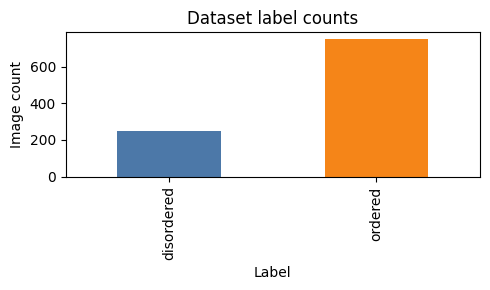

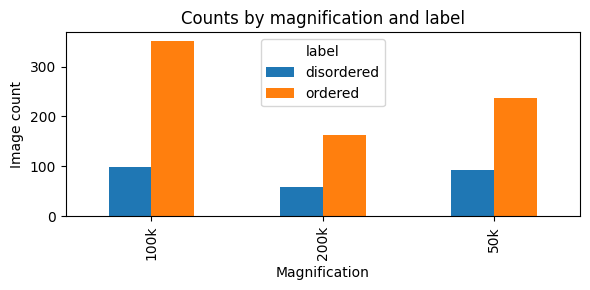

In [14]:
label_counts = metadata["label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
label_counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
ax.set_xlabel("Label")
ax.set_ylabel("Image count")
ax.set_title("Dataset label counts")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "label_counts.png", dpi=200)
plt.show()

pivot = mag_label_counts.pivot(index="mag", columns="label", values="count").fillna(0)
fig, ax = plt.subplots(figsize=(6, 3))
pivot.plot(kind="bar", ax=ax)
ax.set_xlabel("Magnification")
ax.set_ylabel("Image count")
ax.set_title("Counts by magnification and label")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "magnification_label_counts.png", dpi=200)
plt.show()

## 8. Notes for report

- Use these tables to describe class balance and imaging-parameter coverage.
- Do not train on kv, mm, magnification, sample, or area as model features.